# App-26 — Covering Arrays : tester les interactions possibles, auditer les garanties

> **Navigation** : [Applications Search](../README.md) · [CSP-3 (CP-SAT avancé)](../../Part2-CSP/CSP-3-Advanced.ipynb) · [CSP-5 (optimisation)](../../Part2-CSP/CSP-5-Optimization.ipynb)

## Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. définir un *covering array* $CA(N;t,k,v)$ et construire un **oracle de couverture indépendant** ;
2. distinguer une interaction **manquante** d'une interaction **sémantiquement impossible** ;
3. résoudre exactement une petite instance par **set cover CP-SAT**, en lisant statut, incumbent et borne ;
4. comparer cette référence à deux constructions approchées : une extension **IPOG-like** déterministe et une recherche **AETG-like** semée ;
5. auditer les limites d'une garantie expérimentale : borne inférieure, time-out, reproductibilité et validation.

**Prérequis** : combinatoire élémentaire, [CSP-3](../../Part2-CSP/CSP-3-Advanced.ipynb). **Durée estimée** : 55 min.

## Hommage à un travail étudiant

Ce notebook distille le projet **H4 — Covering Arrays** du cours EPITA SCIA *Programmation par Contraintes* 2026, réalisé par **Valérian Pichot** ([Valhallave](https://github.com/Valhallave)) : [répertoire source](https://github.com/jsboigeEpita/2026-Epita-Programmation-par-Contraintes/tree/main/H4-Covering-Arrays), [PR #58](https://github.com/jsboigeEpita/2026-Epita-Programmation-par-Contraintes/pull/58), commit `75000d6d`, licence MIT.

Le projet étudiant apporte le geste central — optimiser un tableau de tests avec CP-SAT, puis le comparer à IPOG et AETG — et une instance à contraintes sémantiques. La reproduction fraîche a confirmé le cœur du modèle mais aussi deux fragilités fécondes : les cellules de benchmark appellent `itertooCPSATGeneratorls` au lieu de `itertools.product`, et le validateur annonce comme « manquantes » des interactions qui sont en réalité impossibles sous les contraintes. CoursIA **réécrit** donc l'expérience : aucun code étudiant n'est importé ; l'oracle, le modèle exact et les baselines sont indépendants, plus petits et entièrement exécutables.

## 1. Environnement et contrat reproductible

Toutes les instances sont générées localement. L'exact utilise un seul worker CP-SAT ; l'heuristique randomisée reçoit une graine explicite. Le notebook n'a besoin ni du dépôt PrCon ni d'un accès réseau.

In [1]:
import itertools
import random
import sys
import time
from collections import defaultdict

import matplotlib.pyplot as plt
import pandas as pd
from ortools.sat.python import cp_model

print(f"Python {sys.version.split()[0]} | OR-Tools {__import__('ortools').__version__} | pandas {pd.__version__}")
print("Contrat : données générées localement | CP-SAT 1 worker | AETG-like seed=42")
print("Source : PrCon H4, Valérian Pichot, PR #58, commit 75000d6d (MIT)")

Python 3.13.14 | OR-Tools 9.15.6755 | pandas 2.3.3
Contrat : données générées localement | CP-SAT 1 worker | AETG-like seed=42
Source : PrCon H4, Valérian Pichot, PR #58, commit 75000d6d (MIT)


**Interprétation.** Le contrat fixe ce qui influe sur la reproductibilité. Le temps restera dépendant de la machine, mais les suites construites et les statuts seront comparables : aucune graine implicite ni fichier distant ne se cache dans l'expérience.

## 2. Couvrir des interactions, pas seulement des valeurs

Pour $k$ paramètres, chacun doté d'un domaine, une interaction de force $t$ choisit $t$ paramètres et une valeur pour chacun. Une suite couvre l'interaction si au moins une de ses lignes réalise simultanément ces valeurs. Un $CA(N;t,k,v)$ uniforme contient $N$ lignes, $k$ colonnes, $v$ valeurs par colonne et couvre toutes les interactions de force $t$.

L'oracle ci-dessous ne connaît aucun solveur : il énumère les interactions et vérifie la couverture. C'est précisément cette indépendance qui en fait un bon auditeur.

In [2]:
def all_rows(domains):
    return list(itertools.product(*domains))


def interactions(domains, strength):
    out = set()
    for cols in itertools.combinations(range(len(domains)), strength):
        for values in itertools.product(*(domains[c] for c in cols)):
            out.add(tuple(zip(cols, values)))
    return out


def covered_by_row(row, universe):
    return {inter for inter in universe
            if all(row[col] == value for col, value in inter)}


def audit_suite(suite, universe):
    covered = set().union(*(covered_by_row(row, universe) for row in suite)) if suite else set()
    return {"covered": len(covered), "required": len(universe),
            "missing": universe - covered, "valid": covered == universe}

DOMAINS_4x2 = [range(2)] * 4
U_4x2 = interactions(DOMAINS_4x2, strength=2)
print(f"4 paramètres binaires, force 2 : {len(U_4x2)} interactions")
print(f"Une ligne couvre C(4,2) = {len(covered_by_row((0,0,0,0), U_4x2))} interactions")
print(f"Borne de comptage immédiate : ceil({len(U_4x2)}/6) = 4 lignes (nécessaire, pas suffisante)")

4 paramètres binaires, force 2 : 24 interactions
Une ligne couvre C(4,2) = 6 interactions
Borne de comptage immédiate : ceil(24/6) = 4 lignes (nécessaire, pas suffisante)


**Interprétation.** Il existe $\binom{4}{2}2^2=24$ interactions. Une ligne en couvre exactement $\binom{4}{2}=6$, d'où la borne 4 — équivalente ici à $v^t$. Mais « au moins 4 » ne signifie pas « 4 suffisent » : les interactions couvertes par différentes lignes doivent aussi s'assembler de façon compatible. La borne est un certificat d'impossibilité en dessous, pas une construction.

### Exercice 1 — Auditer une suite incomplète

Construisez une liste `candidate_suite` de quatre lignes binaires, appelez `audit_suite(candidate_suite, U_4x2)` et inspectez une interaction manquante. Une suite de quatre lignes peut-elle atteindre la borne ?

**Indice :** commencez par les quatre combinaisons des deux premières colonnes.

In [3]:
# TODO étudiant : remplacer None par quatre tuples binaires de longueur 4.
candidate_suite = None
print("Exercice à compléter : candidate_suite puis audit_suite(candidate_suite, U_4x2)")

Exercice à compléter : candidate_suite puis audit_suite(candidate_suite, U_4x2)


**Point de contrôle.** La borne 4 n'est pas atteignable pour quatre facteurs binaires de force 2 : l'optimum vaut 5. Une bonne tentative de quatre lignes couvre souvent les quatre combinaisons de chaque paire prise isolément, mais pas simultanément pour les six paires. La section suivante le certifie.

## 3. Référence exacte : un set cover CP-SAT

Pour les petites instances, énumérons toutes les lignes admissibles $r$. Une variable booléenne $x_r$ indique si la ligne est retenue. Pour chaque interaction faisable $u$, on impose

$$\sum_{r \text{ couvre } u} x_r \ge 1,$$

puis on minimise $\sum_r x_r$. Cette formulation est un **set cover exact**. Elle n'est pas le tableau à slots du projet H4 : c'est une reconstruction CoursIA indépendante, choisie parce qu'elle sépare nettement trois objets — lignes admissibles, interactions exigibles et certificat du solveur.

In [4]:
def feasible_universe(domains, strength, row_allowed=lambda _row: True):
    rows = [row for row in all_rows(domains) if row_allowed(row)]
    raw = interactions(domains, strength)
    feasible = {u for u in raw if any(u in covered_by_row(row, raw) for row in rows)}
    return rows, raw, feasible


def solve_exact(domains, strength, row_allowed=lambda _row: True, time_limit_s=10.0):
    rows, raw, feasible = feasible_universe(domains, strength, row_allowed)
    model = cp_model.CpModel()
    use = [model.new_bool_var(f"use_{i}") for i in range(len(rows))]
    covers = [covered_by_row(row, feasible) for row in rows]
    for u in feasible:
        model.add(sum(use[i] for i, cov in enumerate(covers) if u in cov) >= 1)
    model.minimize(sum(use))
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit_s
    solver.parameters.num_search_workers = 1
    t0 = time.perf_counter()
    status = solver.solve(model)
    elapsed = time.perf_counter() - t0
    names = {cp_model.OPTIMAL: "OPTIMAL", cp_model.FEASIBLE: "FEASIBLE",
             cp_model.INFEASIBLE: "INFEASIBLE", cp_model.UNKNOWN: "UNKNOWN"}
    suite = [rows[i] for i in range(len(rows))
             if status in (cp_model.OPTIMAL, cp_model.FEASIBLE) and solver.value(use[i])]
    return {"suite": suite, "n": len(suite), "status": names.get(status, str(status)),
            "bound": int(round(solver.best_objective_bound)) if status != cp_model.UNKNOWN else None,
            "time_s": elapsed, "rows_admissible": len(rows),
            "raw_interactions": raw, "feasible_interactions": feasible}

exact_4x2 = solve_exact(DOMAINS_4x2, 2)
audit_4x2 = audit_suite(exact_4x2["suite"], exact_4x2["feasible_interactions"])
print(f"CA(N;2,4,2) : N={exact_4x2['n']} | statut={exact_4x2['status']} | borne={exact_4x2['bound']}")
print(f"Oracle indépendant : {audit_4x2['covered']}/{audit_4x2['required']} interactions, valid={audit_4x2['valid']}")
print("Suite :", exact_4x2["suite"])

CA(N;2,4,2) : N=5 | statut=OPTIMAL | borne=5
Oracle indépendant : 24/24 interactions, valid=True
Suite : [(0, 0, 0, 1), (0, 0, 1, 0), (0, 1, 1, 1), (1, 0, 1, 1), (1, 1, 0, 0)]


**Interprétation.** CP-SAT trouve 5 lignes, l'oracle confirme 24/24, et surtout `OPTIMAL` avec une borne égale à 5 ferme l'intervalle : quatre lignes sont impossibles. Une suite valide seule donne une borne supérieure ; le couple incumbent=5 / borne=5 donne la preuve d'optimalité **pour cette instance et cette formulation**.

### 3.1 Une borne atteinte : $CA(8;3,4,2)$

Pour quatre facteurs binaires et $t=3$, la borne $v^t=8$ est atteignable. C'est un contrôle positif utile : l'algorithme doit retrouver non seulement un optimum non trivial (5 ci-dessus), mais aussi un cas où la borne élémentaire est serrée.

In [5]:
exact_4x3 = solve_exact([range(2)] * 4, 3)
lower_4x3 = 2 ** 3
print(f"CA(N;3,4,2) : borne v^t={lower_4x3} | N={exact_4x3['n']} | "
      f"statut={exact_4x3['status']} | borne solveur={exact_4x3['bound']}")
print(f"Validation : {audit_suite(exact_4x3['suite'], exact_4x3['feasible_interactions'])['valid']}")

CA(N;3,4,2) : borne v^t=8 | N=8 | statut=OPTIMAL | borne solveur=8
Validation : True


**Interprétation.** Les 8 lignes atteignent exactement $2^3$. Ici, l'optimalité pourrait être établie sans branchement complexe : une solution à 8 et la borne combinatoire à 8 suffisent. Le statut du solveur reste utile, mais expliquer **pourquoi** une borne est serrée vaut mieux que traiter `OPTIMAL` comme une boîte noire.

## 4. Contraintes sémantiques : quelles interactions faut-il exiger ?

Supposons quatre options binaires $(A,B,C,D)$ avec deux règles métier :

- $A$ et $B$ ne peuvent pas valoir 1 simultanément ;
- $C=1 \Rightarrow D=1$.

Un test doit respecter les règles. Par conséquent, les interactions `(A=1,B=1)` et `(C=1,D=0)` ne sont pas « oubliées » : elles n'ont aucune extension vers une ligne admissible. Un validateur naïf qui exige l'univers cartésien complet produira un faux verdict négatif.

In [6]:
def semantic_ok(row):
    A, B, C, D = row
    return not (A == 1 and B == 1) and not (C == 1 and D == 0)

constrained = solve_exact([range(2)] * 4, 2, semantic_ok)
naive = audit_suite(constrained["suite"], constrained["raw_interactions"])
aware = audit_suite(constrained["suite"], constrained["feasible_interactions"])
infeasible = constrained["raw_interactions"] - constrained["feasible_interactions"]

print(f"Lignes admissibles : {constrained['rows_admissible']}/16")
print(f"Interactions cartésiennes : {len(constrained['raw_interactions'])}")
print(f"Interactions faisables    : {len(constrained['feasible_interactions'])}")
print(f"Suite exacte : N={constrained['n']} ({constrained['status']}, borne={constrained['bound']})")
print(f"Validateur naïf : valid={naive['valid']}, {len(naive['missing'])} prétendues manquantes")
print(f"Validateur conscient : valid={aware['valid']}, {len(aware['missing'])} manquante")
print("Interactions impossibles :", sorted(infeasible))

Lignes admissibles : 9/16
Interactions cartésiennes : 24
Interactions faisables    : 22
Suite exacte : N=5 (OPTIMAL, borne=5)
Validateur naïf : valid=False, 2 prétendues manquantes
Validateur conscient : valid=True, 0 manquante
Interactions impossibles : [((0, 1), (1, 1)), ((2, 1), (3, 0))]


**Interprétation.** Le même tableau reçoit deux verdicts opposés. Le validateur naïf réclame 24 interactions et en dit 2 manquantes ; l'oracle conscient n'en réclame que 22 et valide la suite. Les deux « manquantes » sont exactement les règles interdites. C'est le défaut reproduit dans l'esprit de l'appareil H4 : sur l'instance étudiante plus grande, 38 interactions avaient été signalées alors qu'elles étaient sémantiquement infaisables. Le nombre change avec l'instance ; la cause est la même.

### Exercice 2 — Ajouter une règle métier

Ajoutez la règle $B=1 \Rightarrow D=0$ à `semantic_ok`, puis recalculez les lignes admissibles, les interactions faisables et l'optimum. Ne modifiez ni l'oracle ni le solveur.

**Indice :** une bonne séparation des responsabilités fait de cette extension une modification d'une seule fonction.

In [7]:
def semantic_ok_extended(row):
    # TODO étudiant : conserver semantic_ok(row) et ajouter B=1 => D=0.
    return semantic_ok(row)

extended_result = None  # attendu : solve_exact([range(2)] * 4, 2, semantic_ok_extended)
print("Exercice à compléter : règle supplémentaire puis nouvel audit")

Exercice à compléter : règle supplémentaire puis nouvel audit


**Point de contrôle.** Vérifiez d'abord que chaque ligne renvoyée satisfait les trois règles, puis que `audit_suite(..., feasible_interactions)` est vrai. Le nombre d'interactions exigibles peut diminuer sans que la qualité du test se dégrade : le domaine métier s'est resserré.

## 5. Deux constructions approchées

Un exact devient coûteux quand le nombre de lignes candidates $\prod_i |D_i|$ et le nombre d'interactions explosent. Deux familles historiques construisent alors rapidement une suite :

- **IPOG** (*In-Parameter-Order General*) étend les paramètres dans un ordre fixé ;
- **AETG** génère plusieurs lignes candidates et garde celle qui couvre le plus d'interactions encore absentes.

Les fonctions suivantes sont volontairement nommées **IPOG-like** et **AETG-like** : ce sont deux gloutons de set cover inspirés par leurs gestes (ordre fixe, puis tie-break semé), **pas des implémentations d'IPOG ou d'AETG**. Elles n'en reproduisent ni l'extension horizontale/verticale, ni la génération d'un pool de candidats, ni les garanties.

In [8]:
def greedy_cover(domains, strength, row_allowed=lambda _row: True,
                 candidate_order=None):
    rows, _raw, universe = feasible_universe(domains, strength, row_allowed)
    ordered = candidate_order(rows, universe) if candidate_order else rows
    uncovered, suite = set(universe), []
    while uncovered:
        best = max(ordered, key=lambda row: len(covered_by_row(row, uncovered)))
        gain = covered_by_row(best, uncovered)
        if not gain:
            raise RuntimeError("Aucune ligne candidate ne couvre le résidu")
        suite.append(best)
        uncovered -= gain
        ordered = [row for row in ordered if row != best]
    return suite


def ipog_like(domains, strength, row_allowed=lambda _row: True):
    # Ordre lexicographique déterministe, puis set-cover glouton.
    return greedy_cover(domains, strength, row_allowed)


def aetg_like(domains, strength, row_allowed=lambda _row: True, seed=42):
    rng = random.Random(seed)
    def randomized(rows, _universe):
        rows = list(rows)
        rng.shuffle(rows)
        # La permutation semée tranche les ex aequo du max glouton.
        return rows
    return greedy_cover(domains, strength, row_allowed, randomized)

for name, builder in [("IPOG-like", ipog_like), ("AETG-like seed=42", aetg_like)]:
    suite = builder(DOMAINS_4x2, 2)
    audit = audit_suite(suite, U_4x2)
    print(f"{name:18s}: N={len(suite)} | couverture={audit['covered']}/{audit['required']} | valid={audit['valid']}")

IPOG-like         : N=6 | couverture=24/24 | valid=True
AETG-like seed=42 : N=6 | couverture=24/24 | valid=True


**Interprétation.** Les deux constructions produisent ici une suite valide rapidement, mais `valid=True` ne dit rien sur la minimalité. L'exact donne la référence N=5 ; si une heuristique renvoie davantage, l'écart est mesurable. La graine d'AETG-like ne rend pas l'heuristique exacte : elle rend seulement l'expérience répétable.

### 5.1 Benchmark croisé sur petites instances

Comparons les tailles, tout en gardant quatre colonnes distinctes : statut exact, incumbent, borne et tailles heuristiques. Cette séparation empêche de présenter une solution sous time-out comme un optimum.

In [9]:
BENCHMARKS = [
    ("binaire k=4 t=2", [range(2)] * 4, 2, lambda _r: True),
    ("binaire k=5 t=2", [range(2)] * 5, 2, lambda _r: True),
    ("ternaire k=4 t=2", [range(3)] * 4, 2, lambda _r: True),
    ("contraint k=4 t=2", [range(2)] * 4, 2, semantic_ok),
]
rows = []
for name, domains, strength, allowed in BENCHMARKS:
    exact = solve_exact(domains, strength, allowed, time_limit_s=15)
    ipo = ipog_like(domains, strength, allowed)
    aetg = aetg_like(domains, strength, allowed, seed=42)
    ipo_audit = audit_suite(ipo, exact["feasible_interactions"])
    aetg_audit = audit_suite(aetg, exact["feasible_interactions"])
    rows.append({"instance": name, "interactions": len(exact["feasible_interactions"]),
                 "exact_N": exact["n"], "statut": exact["status"],
                 "borne": exact["bound"], "IPOG_like_N": len(ipo),
                 "AETG_like_N": len(aetg),
                 "heuristiques_valides": ipo_audit["valid"] and aetg_audit["valid"],
                 "temps_exact_s": round(exact["time_s"], 4)})
bench = pd.DataFrame(rows)
display(bench)

,instance,interactions,exact_N,statut,borne,IPOG_like_N,AETG_like_N,heuristiques_valides,temps_exact_s
0,binaire k=4 t=2,24,5,OPTIMAL,5,6,6,True,0.0033
1,binaire k=5 t=2,40,6,OPTIMAL,6,6,7,True,0.8147
2,ternaire k=4 t=2,54,9,FEASIBLE,0,9,10,True,14.9900
3,contraint k=4 t=2,22,5,OPTIMAL,5,6,6,True,0.0006


**Interprétation.** Le tableau est l'objet scientifique, pas un classement universel. Sur ces petites instances, l'exact certifie la référence lorsque `statut=OPTIMAL` et `borne=exact_N`. Les colonnes IPOG-like/AETG-like sont des upper bounds valides après passage de l'oracle. Un autre ordre ou une autre graine peut modifier AETG-like ; aucune différence d'une ligne ne doit être surinterprétée.

### 5.2 Visualiser l'écart à l'exact

La figure encode seulement la taille de suite. Les temps exacts restent dans le tableau précédent : les mélanger sur le même axe suggérerait à tort une comparaison stable entre machines.

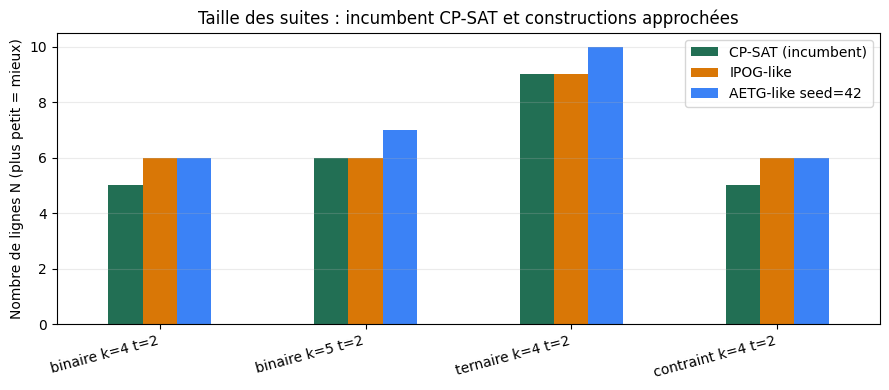

Suites heuristiques validées par l'oracle : True


In [10]:
plot_df = bench.set_index("instance")[["exact_N", "IPOG_like_N", "AETG_like_N"]]
ax = plot_df.plot(kind="bar", figsize=(9, 4), color=["#226f54", "#d97706", "#3b82f6"])
ax.set_ylabel("Nombre de lignes N (plus petit = mieux)")
ax.set_xlabel("")
ax.set_title("Taille des suites : incumbent CP-SAT et constructions approchées")
ax.legend(["CP-SAT (incumbent)", "IPOG-like", "AETG-like seed=42"])
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()
print(f"Suites heuristiques validées par l'oracle : {bench['heuristiques_valides'].all()}")

**Interprétation.** Quand `statut=OPTIMAL` et `borne=exact_N`, une barre heuristique au niveau de l'incumbent montre un optimum **retrouvé sur cette instance**, sans garantie générale. Si le statut est seulement `FEASIBLE`, une égalité de hauteur signifie uniquement « même meilleure taille observée ». Une barre plus haute mesure un coût en tests supplémentaires. Dans tous les cas, la validité vient de l'oracle ; la minimalité vient uniquement d'une borne fermée par l'exact.

### Exercice 3 — Sensibilité d'AETG-like à la graine

Exécutez `aetg_like` pour les graines 0 à 19 sur l'instance ternaire $(k=4,t=2,v=3)`. Tracez la distribution des tailles et comparez le meilleur résultat à l'exact.

**Indice :** stockez `len(aetg_like(..., seed=s))` dans une liste. Une meilleure graine n'est pas une preuve.

In [11]:
# TODO étudiant : remplir aetg_sizes avec 20 tailles, une par graine.
aetg_sizes = None
print("Exercice à compléter : seeds 0..19, tailles AETG-like et histogramme")

Exercice à compléter : seeds 0..19, tailles AETG-like et histogramme


**Point de contrôle.** La dispersion éventuelle mesure la sensibilité au tie-break aléatoire. Le minimum des 20 essais est une meilleure **solution observée**, jamais une borne inférieure. Pour parler d'optimum, comparez-le à `exact_N` avec statut `OPTIMAL` et borne fermée.

## 6. Lire un time-out sans inventer une preuve

CP-SAT peut s'arrêter avec une solution `FEASIBLE` et une meilleure borne strictement plus petite. Le contrat scientifique est alors un intervalle :

$$\text{borne} \le N^* \le \text{incumbent}.$$

L'exemple suivant ne dépend pas d'un time-out fragile : il transforme le résultat certifié du benchmark en fiche de lecture et montre les formulations autorisées selon le statut.

In [12]:
def evidence_statement(result):
    if result["status"] == "OPTIMAL":
        return f"optimum certifié N={result['n']} (borne={result['bound']})"
    if result["status"] == "FEASIBLE":
        return f"solution N={result['n']}, optimum inconnu dans [{result['bound']}, {result['n']}]"
    return f"aucune solution certifiée ({result['status']})"

certified = solve_exact([range(2)] * 5, 2, time_limit_s=15)
synthetic_timeout = dict(certified, status="FEASIBLE", n=certified["n"] + 2,
                         bound=certified["bound"])
print("Lecture du run réel      :", evidence_statement(certified))
print("Lecture correcte FEASIBLE:", evidence_statement(synthetic_timeout))
print("Formulation interdite    : 'N=... est optimal' quand incumbent != borne ou statut != OPTIMAL")

Lecture du run réel      : optimum certifié N=6 (borne=6)
Lecture correcte FEASIBLE: solution N=8, optimum inconnu dans [6, 8]
Formulation interdite    : 'N=... est optimal' quand incumbent != borne ou statut != OPTIMAL


**Interprétation.** La seconde ligne est un exemple de **lecture**, pas un faux run présenté comme mesure : ses valeurs sont explicitement synthétiques. Elle formalise le défaut éditorial fréquent « le solveur a rendu une suite, donc elle est optimale ». Sous time-out, on rapporte l'intervalle et le statut ; on ne gomme ni la borne ni l'incertitude.

## 7. Limites honnêtes

| Résultat | Ce qu'il établit | Ce qu'il n'établit pas |
|---|---|---|
| Oracle 24/24 ou 22/22 | couverture de l'univers fourni | minimalité de la suite |
| `OPTIMAL`, incumbent = borne | optimum de l'instance finie modélisée | formule générale de $CAN(t,k,v)$ |
| Borne $v^t$ atteinte sur $(4,3,2)$ | optimalité par borne serrée | borne serrée pour tout $k,t,v$ |
| Validateur constraint-aware | seules les interactions extensibles sont exigées | correction des règles métier elles-mêmes |
| IPOG-like / AETG-like | baselines rapides et suites validées | implémentations industrielles d'IPOG/AETG, ni garantie de minimalité |
| Graine 42 | répétabilité du run randomisé | robustesse à toutes les graines |
| Benchmark de quatre petites instances | comparaison contrôlée locale | classement universel des algorithmes |

La formulation set-cover énumère $\prod_i |D_i|$ lignes candidates : elle est excellente comme oracle pédagogique, pas comme solveur industriel de grande taille. Le projet H4 utilise justement un tableau à slots CP-SAT pour dépasser cette limite, au prix d'une modélisation et d'un audit plus délicats.

## 8. Ponts avec CoursIA

- [CSP-3 — CP-SAT avancé](../../Part2-CSP/CSP-3-Advanced.ipynb) : variables booléennes, contraintes réifiées et lecture des statuts ;
- [CSP-5 — Optimisation](../../Part2-CSP/CSP-5-Optimization.ipynb) : incumbent, borne et différence entre faisabilité et optimalité ;
- [App-20 — Sudoku Benchmark](App-20-SudokuBenchmark-Python.ipynb) : autre comparaison d'algorithmes sous oracle commun ;
- [App-24 — MAPF Guarantee Audit](../Hybrid/App-24-MAPF-Guarantee-Audit.ipynb) : même discipline, séparer solution valide, optimum observé et garantie prouvée.

Le projet H4 reste la source du geste et de la question : [dépôt](https://github.com/jsboigeEpita/2026-Epita-Programmation-par-Contraintes/tree/main/H4-Covering-Arrays) (MIT), notebook, solveur CP-SAT, IPOG, AETG et slides — non recopiés ici.

## 9. Conclusion

Le geste transmis par **Valérian Pichot** est de traiter la réduction d'une campagne de tests comme un problème de contraintes : couvrir toutes les interactions pertinentes avec le moins de lignes possible, puis confronter exact et heuristiques. La distillation CoursIA ajoute un appareil d'audit indépendant et une question préalable : **toutes les interactions cartésiennes sont-elles réellement possibles ?**

Trois niveaux de preuve doivent rester séparés : l'oracle établit la **validité** d'une suite ; une solution donne une **borne supérieure** ; un statut `OPTIMAL` avec borne fermée établit la **minimalité sur l'instance**. Les contraintes sémantiques ajoutent un niveau zéro : définir correctement l'univers exigible. Sans lui, même un validateur parfaitement codé peut produire un verdict scientifiquement faux.